# design of a servomechanism

This notebook uses the equation for damped harmonic motion, written in standard engineering notation, to model a servo mechanism.

In [1]:
using Plots

In [2]:
using SymPy

### 1. defining the solution

We start with the transfer function using the $\zeta$ and $\omega$ notation of damped harmonic motion.

$$
    G(s) = \frac{1}{s} - \frac{s}{s^2 + 2 \zeta \omega s + \omega^2}.
$$

In [3]:
s, t, omega, zeta = Sym("s, t, omega, zeta")

(s, t, omega, zeta)

In [4]:
G = 1/s - s/(s^2 + 2*zeta*omega*s + omega^2)

               s                 1
- ---------------------------- + -
       2                     2   s
  omega  + 2*omega*s*zeta + s     

## 2. simulate

The symbolic form of the solution in the time domain is derived on the lecture slides.

In [5]:
tau = Sym("tau")

tau

In [6]:
ytau = 1 - (1/sqrt(1-zeta^2))*exp(-zeta*tau)*cos(tau*sqrt(1-zeta^2) + atan(zeta/sqrt(1-zeta^2)))

                  /       ___________                       \
     -tau*zeta    |      /         2        /     zeta     \|
    e         *cos|tau*\/  1 - zeta   + atan|--------------||
                  |                         |   ___________||
                  |                         |  /         2 ||
                  \                         \\/  1 - zeta  //
1 - ---------------------------------------------------------
                             ___________                     
                            /         2                      
                          \/  1 - zeta                       

In [7]:
yt1 = ytau.subs(Dict(zeta=>0.1))

                      -0.1*tau                                             
1 - 1.00503781525921*e        *cos(0.99498743710662*tau + 0.10016742116156)

In [8]:
y1(T) = yt1.subs(Dict(tau=>T))

y1 (generic function with 1 method)

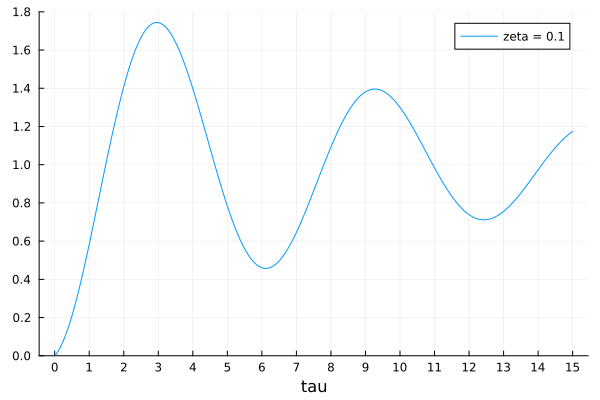

In [9]:
plot(0:0.01:15, y1, label="zeta = 0.1", xlabel="tau", xticks=0:1:15, yticks=0.0:0.2:1.8, ylims=[0,1.8])

In [10]:
# savefig("figservozeta01.png")

In [11]:
yt2 = ytau.subs(Dict(zeta=>0.2))
yt4 = ytau.subs(Dict(zeta=>0.4))
yt6 = ytau.subs(Dict(zeta=>0.6))
yt7 = ytau.subs(Dict(zeta=>0.7))
yt8 = ytau.subs(Dict(zeta=>0.8))

                      -0.8*tau                                 
1 - 1.66666666666667*e        *cos(0.6*tau + 0.927295218001612)

In [12]:
y2(T) = yt2.subs(Dict(tau=>T))
y4(T) = yt4.subs(Dict(tau=>T))
y6(T) = yt6.subs(Dict(tau=>T))
y7(T) = yt7.subs(Dict(tau=>T))
y8(T) = yt8.subs(Dict(tau=>T))

y8 (generic function with 1 method)

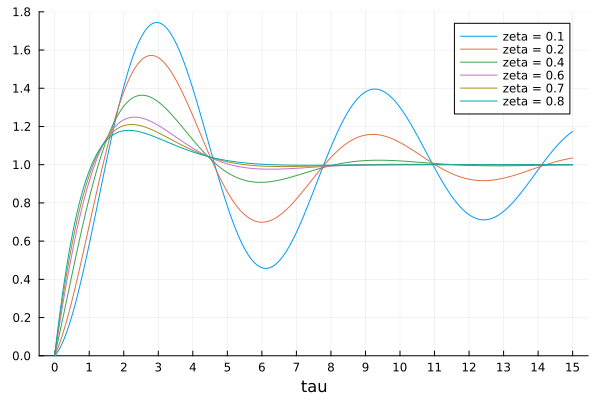

In [13]:
plot!(0:0.01:15, y2, label="zeta = 0.2")
plot!(0:0.01:15, y4, label="zeta = 0.4")
plot!(0:0.01:15, y6, label="zeta = 0.6")
plot!(0:0.01:15, y7, label="zeta = 0.7")
plot!(0:0.01:15, y8, label="zeta = 0.8")

In [14]:
# savefig("figservozetas.png")

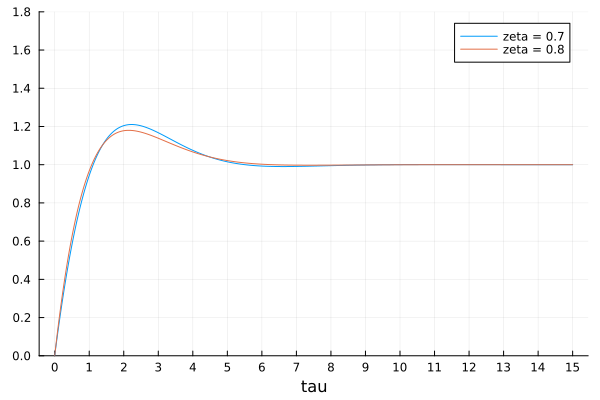

In [15]:
plot(0:0.01:15, y7, label="zeta = 0.7", xlabel="tau", xticks=0:1:15, yticks=0.0:0.2:1.8, ylims=[0,1.8])
plot!(0:0.01:15, y8, label="zeta = 0.8", xlabel="tau", yticks=0.0:0.2:1.8, ylims=[0,1.8])

In [16]:
# savefig("figservozeta78.png")

With $\zeta = 0.7$, we see that the overshoot is slightly above 20%.

In [17]:
y7(2.1)

1.20846960471506

In [18]:
y7(1)

0.943560113247383

In [19]:
y8(1)

0.967433093326487

In [20]:
y8(1.1)

1.01140524609714

In [21]:
y7(1.5)

1.13344546176687

In [22]:
y8(1.5)

1.12735271710978